# NHR Workshop on Practical Quantum Computing 2026 - Interactive Coding Session 1
# Quantum Computing Basics

## Importing software packages

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import qiskit

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector

In [3]:
print("Python:", sys.version)
print("Executable:", sys.executable)
print("Qiskit version:", qiskit.__version__)

Python: 3.10.20 | packaged by conda-forge | (main, Mar  5 2026, 16:42:22) [GCC 14.3.0]
Executable: /home/sacvj/miniconda3/envs/quantum-workshop/bin/python
Qiskit version: 2.4.1


## Single qubits, gates and the Bloch sphere

First, we will look at how to create a qubit with which we can work with in Qiskit. The cell below defines a "blank" quantum circuit with a single qubit. The qubit is automatically initialized to be in the state $\ket{0}$. 

A good way to visualize qubits is with the Bloch sphere. To do this, we need the final quantum state that the circuit "produces".

In this case, we don't apply any gates to our qubit, so the final state produced by the circuit is simply the initial state, so the qubit is in the state $\ket{0}$.

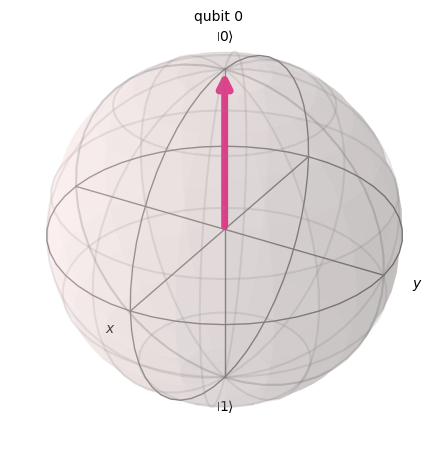

In [4]:
qc = QuantumCircuit(1)

state = Statevector.from_instruction(qc)

display(plot_bloch_multivector(state))

In quantum computing, we apply gates to our qubits to change their quantum state.

Below, we create another qubit, and apply an $X$ gate to it. The $X$ gate "flips" the qubit, which means that if the qubit was initially in state $\ket{0}$, it is in the state $\ket{1}$ state after we apply the $X$ gate.

In general, an $X$ gate applied to any qubit state "rotates" the qubit's state around the x-axis by an angle of 180°. You can run the cells below to see what an $X$ gate does to different qubit states.

Before the X gate:
Statevector: Statevector([1.+0.j, 0.+0.j],
            dims=(2,))


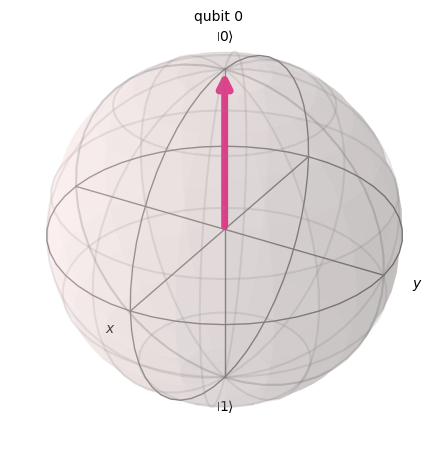

After the X gate:
Statevector: Statevector([0.+0.j, 1.+0.j],
            dims=(2,))


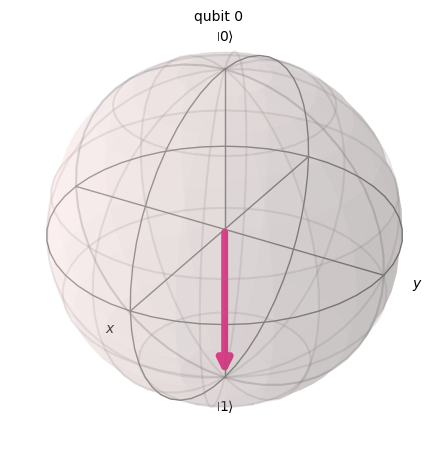

In [5]:
qc = QuantumCircuit(1)

state = Statevector.from_instruction(qc)

print("Before the X gate:")
print("Statevector:", state)
display(plot_bloch_multivector(state))

qc.x(0)

state = Statevector.from_instruction(qc)

print("After the X gate:")
print("Statevector:", state)
display(plot_bloch_multivector(state))

Before the X gate:
Statevector: Statevector([0.92387953+0.j, 0.38268343+0.j],
            dims=(2,))


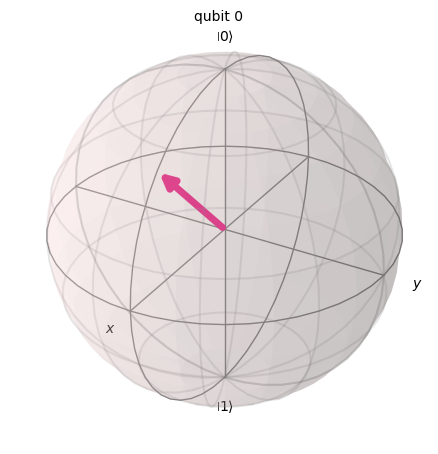

After the X gate:
Statevector: Statevector([0.38268343+0.j, 0.92387953+0.j],
            dims=(2,))


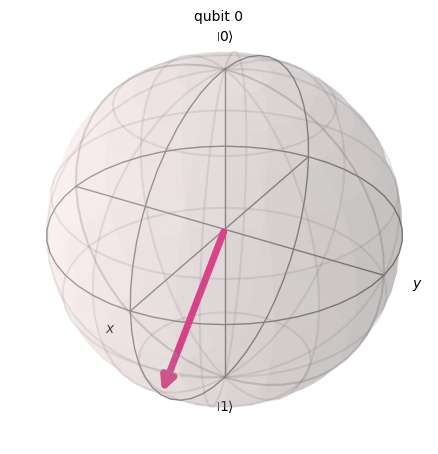

In [6]:
qc = QuantumCircuit(1)
qc.ry(np.pi/4, 0)

state = Statevector.from_instruction(qc)

print("Before the X gate:")
print("Statevector:", state)
display(plot_bloch_multivector(state))

qc.x(0)

state = Statevector.from_instruction(qc)

print("After the X gate:")
print("Statevector:", state)
display(plot_bloch_multivector(state))

Before the X gate:
Statevector: Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))


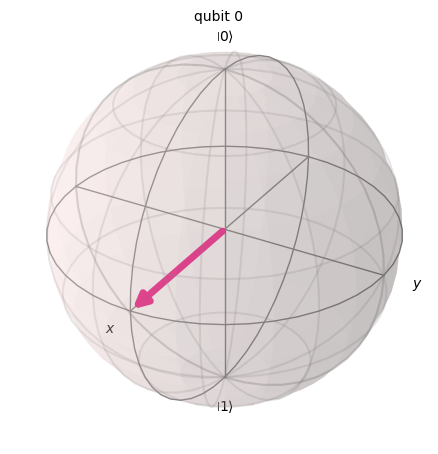

After the X gate:
Statevector: Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))


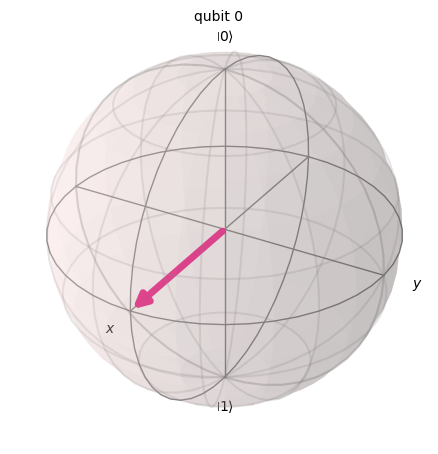

In [7]:
qc = QuantumCircuit(1)
qc.ry(np.pi/2, 0)

state = Statevector.from_instruction(qc)

print("Before the X gate:")
print("Statevector:", state)
display(plot_bloch_multivector(state))

qc.x(0)

state = Statevector.from_instruction(qc)

print("After the X gate:")
print("Statevector:", state)
display(plot_bloch_multivector(state))

The $X$ gate of course is not the only gate that we can apply to a qubit. There are also $Y$ and $Z$ gates, which work in analogy to the $X$ gate, i.e. they flip the qubit by rotating it by 180° around the y- or z-axis of the Bloch sphere, respectively.

The $X$, $Y$ and $Z$ gates are discreet, but there are also continuous gates. In the previous cells, we also used so-called $Y$-rotation gates (e.g. `qc.ry(np.pi/4, 0)`) to prepare the different initial states on which we then applied the $X$ gate. These gates rotate the qubit's state around the y-axis by an arbitrary angle. 

In general, a $R_x(\theta)$, $R_y(\theta)$ or $R_z(\theta)$ gate rotates the qubit's state around the x-, y- or z-axis of the Bloch sphere by the angle $\theta$. 

The $X$, $Y$ and $Z$ gates are basically special cases of the rotation gates, where $\theta = \pi$ (up to a physically irrelevant global phase).


## EXERCISE 1 - HADAMARD GATE

Another very important quantum gate is the Hadamard gate (`H` gate). Unlike the $X$, $Y$ and $Z$ gates, it does not simply rotate the qubit around one of the coordinate axes of the Bloch sphere.

Instead, the Hadamard gate transforms the basis states into superposition states:

$
H|0\rangle = \frac{|0\rangle + |1\rangle}{\sqrt{2}},
\qquad
H|1\rangle = \frac{|0\rangle - |1\rangle}{\sqrt{2}}.
$

Geometrically, the Hadamard gate maps the z-axis of the Bloch sphere onto the x-axis.

The cell below shows the effect of the Hadamard gate on the basis states $\ket{0}$ and $\ket{1})$ geometrically.

Before the Hadamard gates:
Statevector: Statevector([0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j],
            dims=(2, 2))


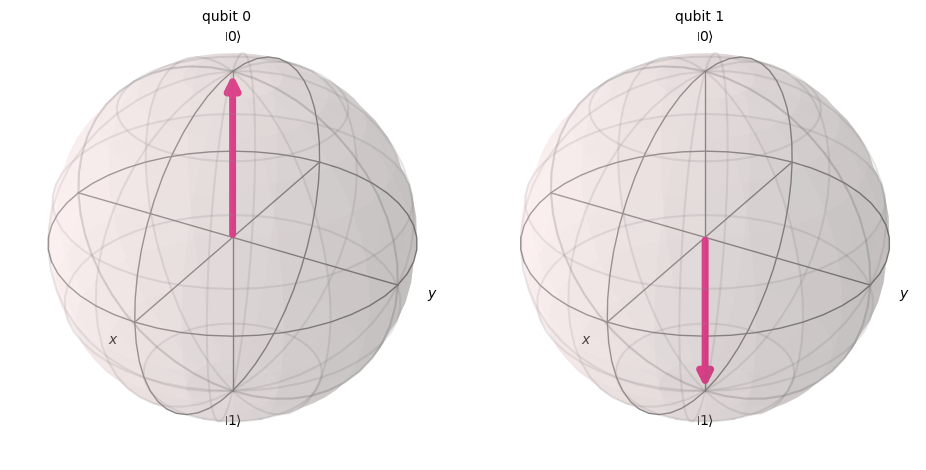

After the Hadamard gates:
Statevector: Statevector([ 0.5+0.j,  0.5+0.j, -0.5+0.j, -0.5+0.j],
            dims=(2, 2))


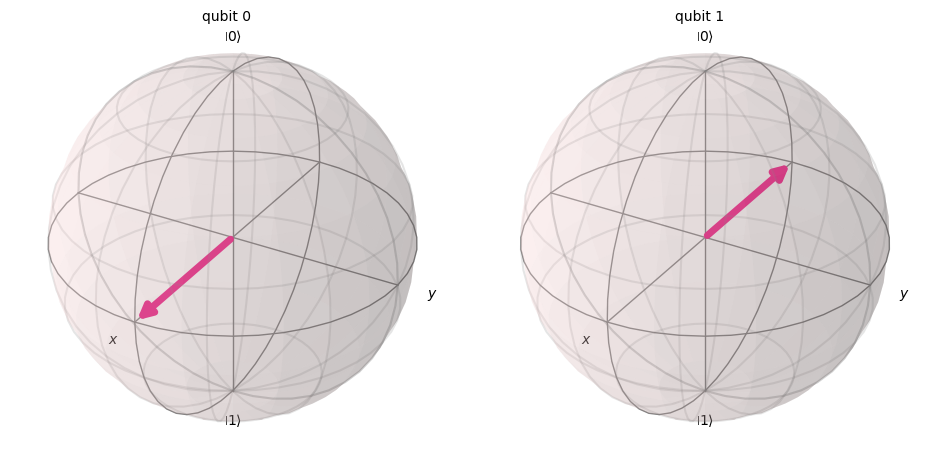

In [9]:
qc = QuantumCircuit(2)
qc.x(1)

state = Statevector.from_instruction(qc)

print("Before the Hadamard gates:")
print("Statevector:", state)
display(plot_bloch_multivector(state))

qc.h(0)
qc.h(1)

state = Statevector.from_instruction(qc)

print("After the Hadamard gates:")
print("Statevector:", state)
display(plot_bloch_multivector(state))

It is now your job, to experiment with the $X$, $Y$, $Z$, $R_x(\theta)$, $R_x(\theta)$ and $R_x(\theta)$ gates, and find a way to represent the Hadamard gate through a combination of these. Also verify, that your own Hadamard gate has the same effect on non-basis states as the "real" Hadamard gate has by using `qc.h(0)`. **Hint**: the solution is NOT simply a rotation around the y-axis!

Before the Hadamard gates:
Statevector: Statevector([0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j],
            dims=(2, 2))


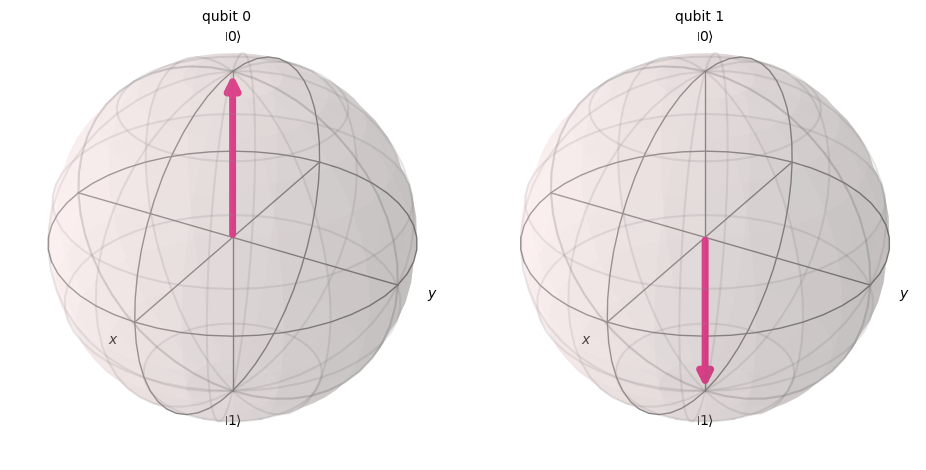

After the Hadamard gates:
Statevector: Statevector([-0.5+0.j, -0.5+0.j,  0.5+0.j,  0.5+0.j],
            dims=(2, 2))


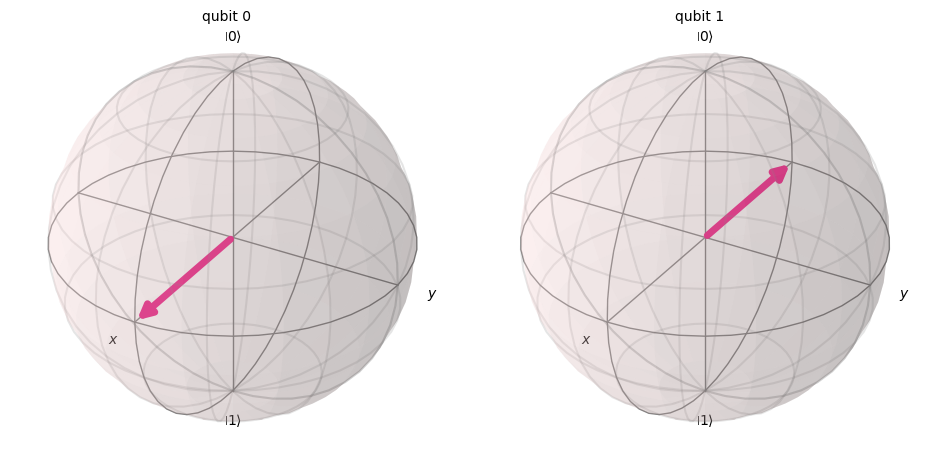

In [23]:
qc = QuantumCircuit(2)
qc.x(1)

state = Statevector.from_instruction(qc)

print("Before the Hadamard gates:")
print("Statevector:", state)
display(plot_bloch_mulfrom qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

qc = QuantumCircuit(1, 1)
qc.h(0)
qc.measure(0, 0)

sim = AerSimulator()tivector(state))

qc.rz(np.pi, 0)
qc.ry(np.pi/2, 0)

qc.rz(np.pi, 1)
qc.ry(np.pi/2, 1)

state = Statevector.from_instruction(qc)

print("After the Hadamard gates:")
print("Statevector:", state)
display(plot_bloch_multivector(state))

## Measurement and multiple qubits

So far, we only looked at how to manipulate the quantum state of a single qubit. However, quantum computers become truly interesting once we start measuring qubits and combining multiple qubits into larger quantum systems.

When we measure a qubit, we do not directly observe its full quantum state. Instead, we obtain a classical measurement result (`0` or `1`) with probabilities determined by the quantum state. **We force it to collapse into one of the eigenstates of the measurement operator**, which in this case are the computational basis states $\ket{0}$ and $\ket{1}$).

For example, the state

$
\frac{|0\rangle + |1\rangle}{\sqrt{2}}
$

will produce the measurement results `0` and `1` with equal probability.

The cell below defines a quantum circuit that produces the state $\ket{\psi}=(\ket{0}+\ket{1})/\sqrt{2}$ by applying a Hadamard gate, and includes a *measurement* operation. 

To get *simulated* measurement results, we use Qiskits *AerSimulator*, which simulates how the circuit would behave on an ideal, noise-free quantum computer.

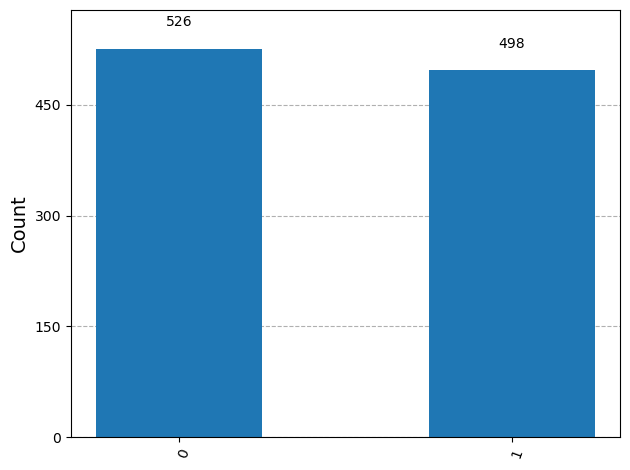

In [30]:
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

qc = QuantumCircuit(1, 1)
qc.h(0)
qc.measure(0, 0)

sim = AerSimulator()
result = sim.run(qc, shots=1024).result()
counts = result.get_counts()

plot_histogram(counts)

Quantum mechanics becomes even more interesting when we combine **multiple qubits**. 

We won't go into too much detail here yet, but we can create *entangled* multi-qubit states, where the measurement outcomes of different qubits become strongly correlated.

One of the simplest examples is the Bell state

$
\frac{|00\rangle + |11\rangle}{\sqrt{2}}.
$

If we measure this state, we will always either obtain `00` or `11`, even though each individual qubit by itself appears random.

In the cell below, we define a quantum circuit with two qubits, entangle them, and perform another simulated measurement.

We will go into more detail abut circuits and multi-qubit cases in the next coding session.

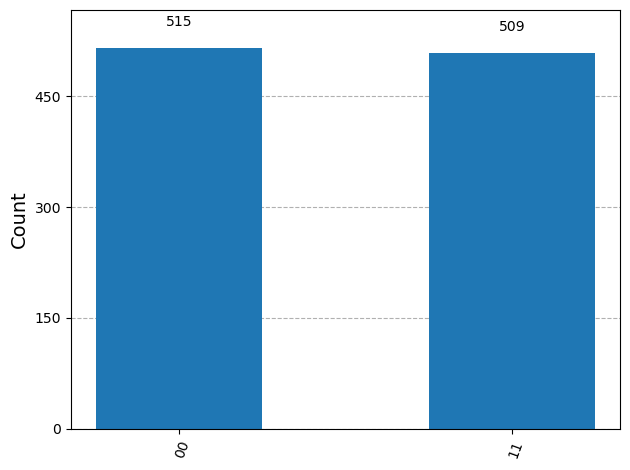

In [32]:
qc = QuantumCircuit(2,2)
qc.h(0)
qc.cx(0,1)
qc.measure(0, 0)
qc.measure(1, 1)

sim = AerSimulator()
result = sim.run(qc, shots=1024).result()
counts = result.get_counts()

plot_histogram(counts)